In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import os
import glob
from pathlib import Path

# Set style for better plots
plt.style.use('default')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12


In [7]:
# get directoris of versions you want to plot
base_dir = Path('.')  # Current directory (plots/)
processed_dir = Path('../data/processed') 
plot_dirs = [item for item in base_dir.iterdir() if 'early' in item.name and item.is_dir()]
print(len(plot_dirs))


8


In [8]:
# Function to find all cutoff directories and load their data
def load_cutoff_data(plot_dirs):
    """Load explain_count.csv data from all cutoffXXXX subdirectories and corresponding case/hospital data"""
    base_dir = Path('.')  # Current directory (plots/)
    processed_dir = Path('../data/processed')  # Path to processed data
    
    cutoff_data = {}
    
    for plot_dir in sorted(plot_dirs):
        csv_file = plot_dir / 'explain_count.csv'
        if csv_file.exists():
            print(f"Loading data from: {plot_dir.name}")
            
            # Load explain count data
            explain_df = pd.read_csv(csv_file)
            explain_df['date'] = pd.to_datetime(explain_df['date'])
            
            # Load corresponding case/hospital data from processed directory
            processed_data_dir = processed_dir / plot_dir.name
            case_data_file = processed_data_dir / 'case_data.csv'
            
            case_df = None
            if case_data_file.exists():
                print(f"  Loading case/hospital data from: {case_data_file}")
                case_df = pd.read_csv(case_data_file)
                
                # Determine if this is case or hospital data based on columns
                if 'date' in case_df.columns:
                    # Case data
                    case_df['date'] = pd.to_datetime(case_df['date'])
                    # Aggregate case data by date (sum across all CBSAs)
                    case_agg = case_df.groupby('date')['CASE_COUNT_7DAY_AVG'].sum().reset_index()
                    case_agg.columns = ['date', 'case_count_7day_avg']
                    data_type = 'case'
                elif 'collection_week' in case_df.columns:
                    # Hospital data
                    case_df['collection_week'] = pd.to_datetime(case_df['collection_week'])
                    # Aggregate hospital data by collection_week (sum across all CBSAs)
                    case_agg = case_df.groupby('collection_week')['total_adult_patients_hospitalized_confirmed_covid_7_day_sum'].sum().reset_index()
                    case_agg.columns = ['date', 'hospital_count_7day_sum']
                    data_type = 'hospital'
                else:
                    print(f"  Warning: Unknown data format in {case_data_file}")
                    case_agg = None
                    data_type = 'unknown'
            else:
                print(f"  Warning: No case_data.csv found in {processed_data_dir}")
                case_agg = None
                data_type = 'unknown'
            
            cutoff_data[plot_dir.name] = {
                'explain_data': explain_df,
                'case_data': case_agg,
                'data_type': data_type,
                'path': plot_dir
            }
        else:
            print(f"Warning: No explain_count.csv found in {plot_dir.name}")
    
    return cutoff_data

# Load all cutoff data
cutoff_data = load_cutoff_data(plot_dirs)
print(f"\nFound {len(cutoff_data)} cutoff configurations:")
for name, info in cutoff_data.items():
    print(f"  - {name} ({info['data_type']} data)")


Loading data from: case_advan_cutoff1000_early
  Loading case/hospital data from: ../data/processed/case_advan_cutoff1000_early/case_data.csv
Loading data from: case_advan_cutoff500_early
  Loading case/hospital data from: ../data/processed/case_advan_cutoff500_early/case_data.csv
Loading data from: case_safegraph_cutoff1000_early
  Loading case/hospital data from: ../data/processed/case_safegraph_cutoff1000_early/case_data.csv
Loading data from: case_safegraph_cutoff500_early
  Loading case/hospital data from: ../data/processed/case_safegraph_cutoff500_early/case_data.csv
Loading data from: hospital_advan_cutoff1000_early
  Loading case/hospital data from: ../data/processed/hospital_advan_cutoff1000_early/case_data.csv
Loading data from: hospital_advan_cutoff500_early
  Loading case/hospital data from: ../data/processed/hospital_advan_cutoff500_early/case_data.csv
Loading data from: hospital_safegraph_cutoff1000_early
  Loading case/hospital data from: ../data/processed/hospital_safeg

\nTesting plot with: case_advan_cutoff1000_early


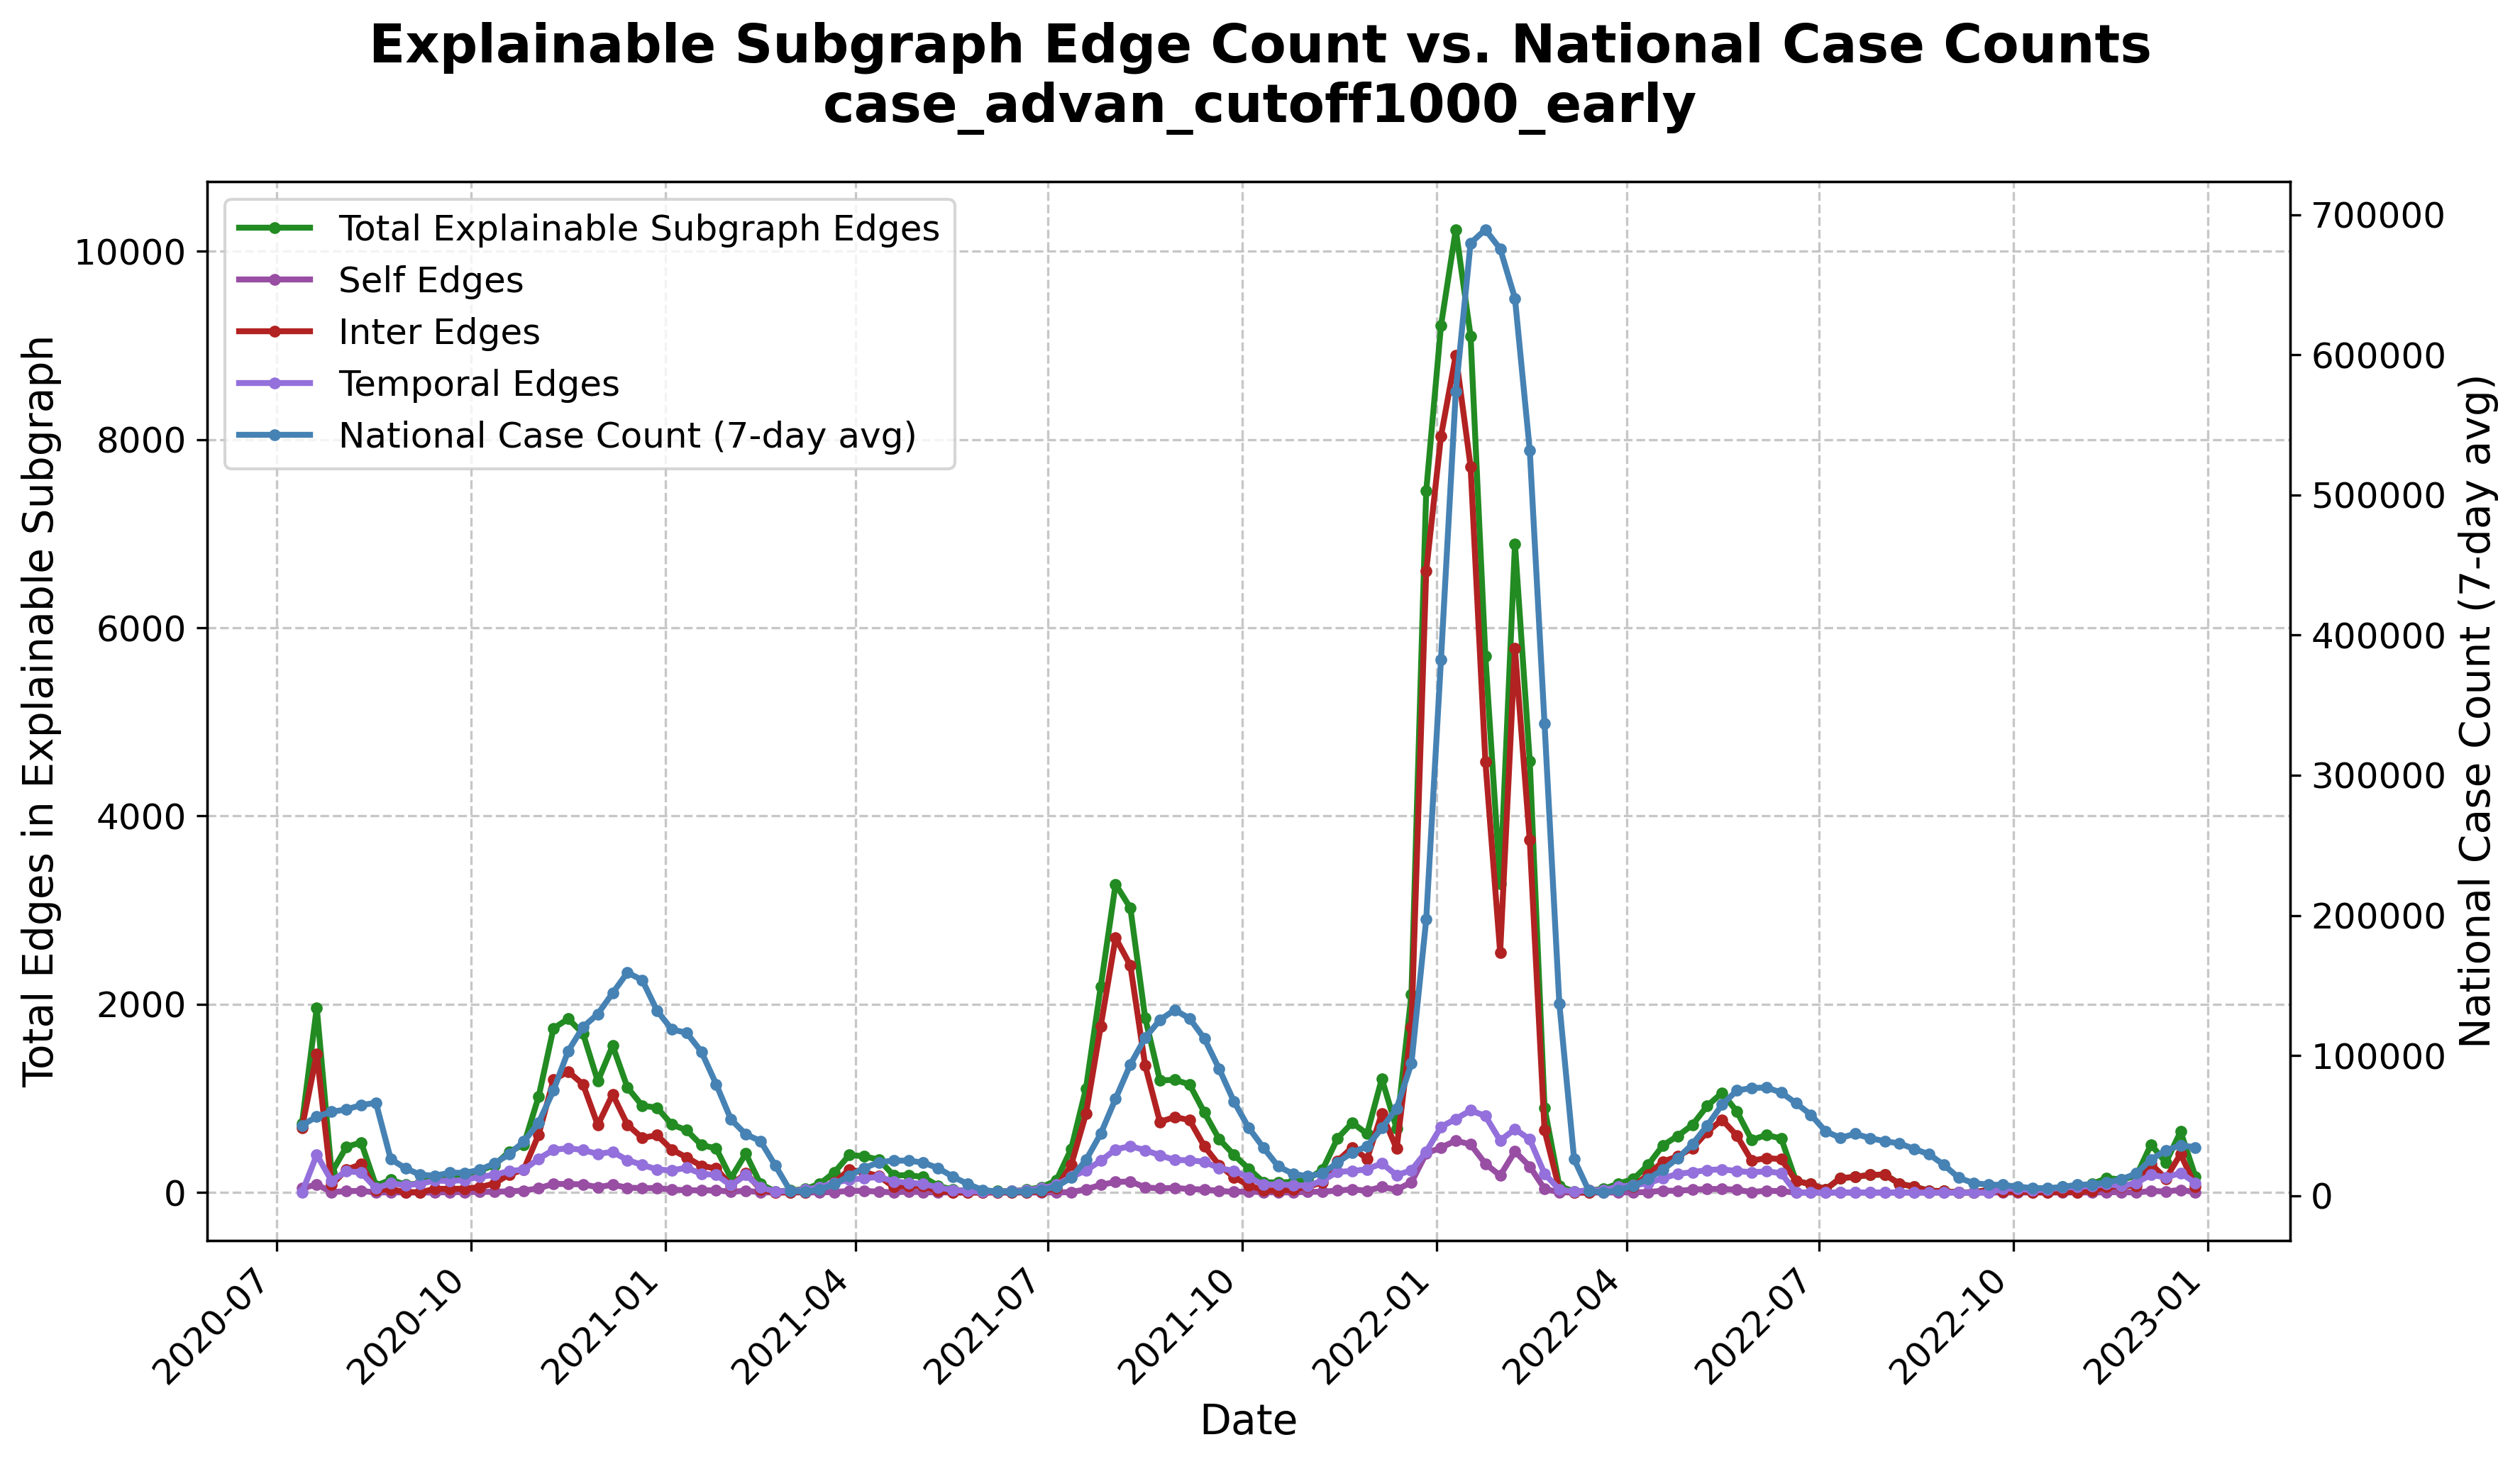

In [9]:
def create_explainable_subgraph_plot(explain_count_df, case_data_df, config_name, data_type, save_path=None):
    """
    Create a plot similar to the one in main_new_data.ipynb showing explainable subgraph edge counts
    with case/hospital data on secondary y-axis
    """
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
    
    # Plot the different edge types on primary y-axis
    line1, = ax.plot(explain_count_df['date'], explain_count_df['total_edge_count'], 
                     '.-', label='Total Explainable Subgraph Edges', color='forestgreen', linewidth=2)
    line2, = ax.plot(explain_count_df['date'], explain_count_df['self_edge_count'], 
                     '.-', label='Self Edges', color='#984ea3', linewidth=2)
    line3, = ax.plot(explain_count_df['date'], explain_count_df['inter_edge_count'], 
                     '.-', label='Inter Edges', color='firebrick', linewidth=2)
    line4, = ax.plot(explain_count_df['date'], explain_count_df['temporal_edge_count'], 
                     '.-', label='Temporal Edges', color='mediumpurple', linewidth=2)
    
    # Primary y-axis formatting
    ax.set_ylabel('Total Edges in Explainable Subgraph', fontsize=14)
    ax.set_xlabel('Date', fontsize=14)
    ax.grid(True, linestyle='dashed', alpha=0.7)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=12, rotation=45)
    
    # Create secondary y-axis for case/hospital data
    lines = [line1, line2, line3, line4]
    
    if case_data_df is not None:
        ax2 = ax.twinx()
        
        if data_type == 'case':
            line5, = ax2.plot(case_data_df['date'], case_data_df['case_count_7day_avg'],
                             ".-", color='steelblue', label='National Case Count (7-day avg)', linewidth=2)
            ax2.set_ylabel('National Case Count (7-day avg)', fontsize=14)
        elif data_type == 'hospital':
            line5, = ax2.plot(case_data_df['date'], case_data_df['hospital_count_7day_sum'],
                             ".-", color='steelblue', label='National Hospital Count (7-day sum)', linewidth=2)
            ax2.set_ylabel('National Hospital Count (7-day sum)', fontsize=14)
        else:
            line5 = None
        
        if line5:
            lines.append(line5)
            ax2.tick_params(axis='y', labelsize=12)
    
    # Legend with all lines
    ax.legend(handles=lines, loc='upper left', fontsize=12)
    
    # Title - use config name directly as requested
    fig.suptitle(f'Explainable Subgraph Edge Count vs. National {data_type.title()} Counts\n{config_name}',
                 fontsize=18, fontweight='bold')
    
    # Adjust layout
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved plot to: {save_path}")
    
    return fig, ax

# Test the plotting function with one configuration
if cutoff_data:
    test_config = list(cutoff_data.keys())[0]
    test_info = cutoff_data[test_config]
    print(f"\\nTesting plot with: {test_config}")
    fig, ax = create_explainable_subgraph_plot(
        test_info['explain_data'], 
        test_info['case_data'], 
        test_config, 
        test_info['data_type']
    )
    plt.show()


In [10]:
# Generate plots for all cutoff configurations and save PDFs
def generate_all_plots(cutoff_data):
    """Generate plots for all cutoff configurations and save PDFs in respective directories"""
    
    print("Generating plots for all cutoff configurations...")
    print("=" * 60)
    
    for config_name, config_info in cutoff_data.items():
        print(f"\\nProcessing: {config_name}")
        
        # Get data and directory path
        explain_data = config_info['explain_data']
        case_data = config_info['case_data']
        data_type = config_info['data_type']
        save_dir = config_info['path']
        
        # Create PDF filename
        pdf_filename = f"explainable_subgraph_edge_count_{config_name}.pdf"
        pdf_path = save_dir / pdf_filename
        
        # Create the plot and save as PDF
        fig, ax = create_explainable_subgraph_plot(
            explain_data, case_data, config_name, data_type, save_path=pdf_path
        )
        
        # Also save as PNG for quick viewing
        png_filename = f"explainable_subgraph_edge_count_{config_name}.png"
        png_path = save_dir / png_filename
        fig.savefig(png_path, bbox_inches='tight', dpi=300)
        print(f"Saved PNG to: {png_path}")
        
        # Close the figure to free memory
        plt.close(fig)
        
        print(f"✓ Completed: {config_name}")
        print(f"  - PDF: {pdf_path}")
        print(f"  - PNG: {png_path}")
    
    print("\\n" + "=" * 60)
    print("All plots generated successfully!")

# Generate all plots
generate_all_plots(cutoff_data)


Generating plots for all cutoff configurations...
\nProcessing: case_advan_cutoff1000_early
Saved plot to: case_advan_cutoff1000_early/explainable_subgraph_edge_count_case_advan_cutoff1000_early.pdf
Saved PNG to: case_advan_cutoff1000_early/explainable_subgraph_edge_count_case_advan_cutoff1000_early.png
✓ Completed: case_advan_cutoff1000_early
  - PDF: case_advan_cutoff1000_early/explainable_subgraph_edge_count_case_advan_cutoff1000_early.pdf
  - PNG: case_advan_cutoff1000_early/explainable_subgraph_edge_count_case_advan_cutoff1000_early.png
\nProcessing: case_advan_cutoff500_early
Saved plot to: case_advan_cutoff500_early/explainable_subgraph_edge_count_case_advan_cutoff500_early.pdf
Saved PNG to: case_advan_cutoff500_early/explainable_subgraph_edge_count_case_advan_cutoff500_early.png
✓ Completed: case_advan_cutoff500_early
  - PDF: case_advan_cutoff500_early/explainable_subgraph_edge_count_case_advan_cutoff500_early.pdf
  - PNG: case_advan_cutoff500_early/explainable_subgraph_edge_c

Saved comparison plot to: explainable_subgraph_comparison.pdf


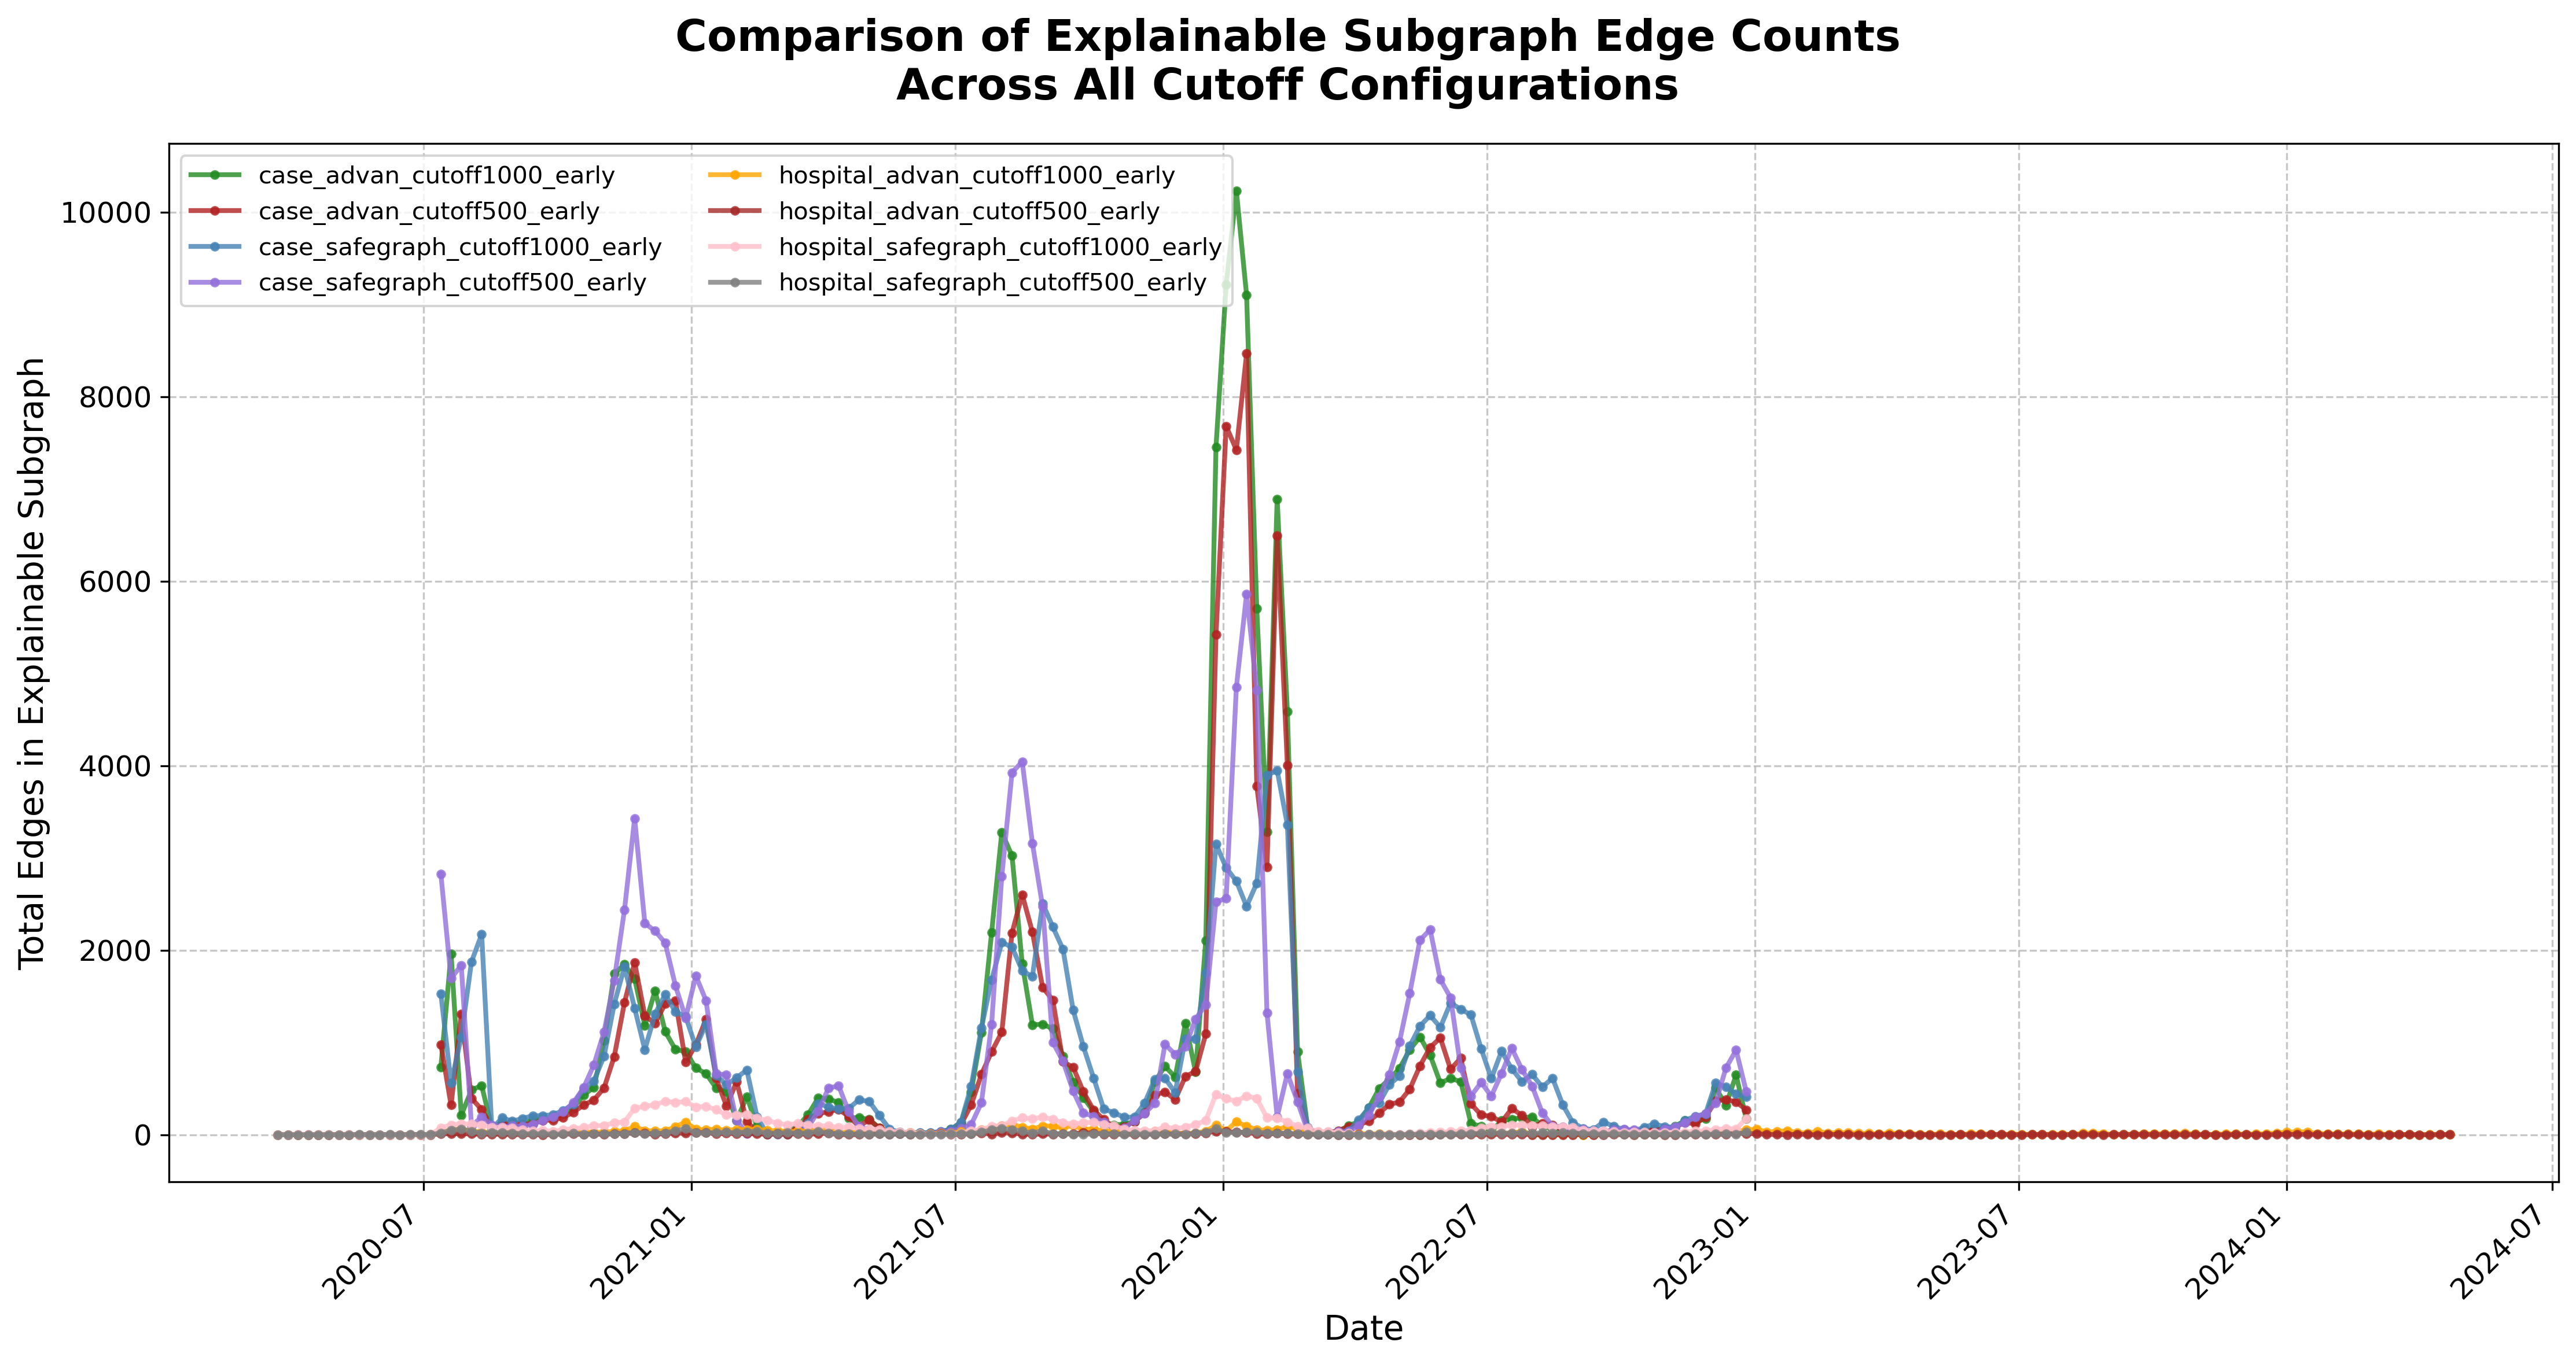

Saved comparison plot as PNG: explainable_subgraph_comparison.png


In [11]:
# Optional: Create a summary comparison plot showing all configurations
def create_comparison_plot(cutoff_data, save_path=None):
    """Create a comparison plot showing total edge counts for all configurations"""
    
    fig, ax = plt.subplots(figsize=(15, 8), dpi=300)
    
    # Color palette for different configurations
    colors = ['forestgreen', 'firebrick', 'steelblue', 'mediumpurple', 
              'orange', 'brown', 'pink', 'gray']
    
    for i, (config_name, config_info) in enumerate(cutoff_data.items()):
        explain_data = config_info['explain_data']
        color = colors[i % len(colors)]
        
        # Plot total edge count for each configuration
        ax.plot(explain_data['date'], explain_data['total_edge_count'], 
                '.-', label=config_name, 
                color=color, linewidth=2, alpha=0.8)
    
    # Formatting
    ax.set_ylabel('Total Edges in Explainable Subgraph', fontsize=14)
    ax.set_xlabel('Date', fontsize=14)
    ax.grid(True, linestyle='dashed', alpha=0.7)
    
    # Format axes
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=12, rotation=45)
    
    # Legend
    ax.legend(loc='upper left', fontsize=10, ncol=2)
    
    # Title
    fig.suptitle('Comparison of Explainable Subgraph Edge Counts\nAcross All Cutoff Configurations', 
                 fontsize=18, fontweight='bold')
    
    # Adjust layout
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved comparison plot to: {save_path}")
    
    return fig, ax

# Create comparison plot
comparison_fig, comparison_ax = create_comparison_plot(cutoff_data, 
                                                     save_path='explainable_subgraph_comparison.pdf')
plt.show()

# Also save as PNG
comparison_fig.savefig('explainable_subgraph_comparison.png', bbox_inches='tight', dpi=300)
print("Saved comparison plot as PNG: explainable_subgraph_comparison.png")


In [12]:
# Summary statistics for each configuration
def print_summary_statistics(cutoff_data):
    """Print summary statistics for each cutoff configuration"""
    
    print("\\n" + "=" * 80)
    print("SUMMARY STATISTICS FOR ALL CUTOFF CONFIGURATIONS")
    print("=" * 80)
    
    for config_name, config_info in cutoff_data.items():
        explain_data = config_info['explain_data']
        case_data = config_info['case_data']
        data_type = config_info['data_type']
        
        print(f"\\n{config_name.upper()}")
        print("-" * 50)
        print(f"Data type: {data_type}")
        print(f"Date range: {explain_data['date'].min().strftime('%Y-%m-%d')} to {explain_data['date'].max().strftime('%Y-%m-%d')}")
        print(f"Total data points: {len(explain_data)}")
        print()
        
        # Statistics for each edge type
        edge_types = ['total_edge_count', 'self_edge_count', 'inter_edge_count', 'temporal_edge_count']
        for edge_type in edge_types:
            values = explain_data[edge_type]
            print(f"{edge_type.replace('_', ' ').title()}:")
            print(f"  Mean: {values.mean():.1f}")
            print(f"  Max:  {values.max():.0f}")
            print(f"  Min:  {values.min():.0f}")
            print(f"  Std:  {values.std():.1f}")
        
        # Statistics for case/hospital data if available
        if case_data is not None:
            print()
            if data_type == 'case':
                values = case_data['case_count_7day_avg']
                print("Case Count (7-day avg):")
            elif data_type == 'hospital':
                values = case_data['hospital_count_7day_sum']
                print("Hospital Count (7-day sum):")
            
            if 'values' in locals():
                print(f"  Mean: {values.mean():.1f}")
                print(f"  Max:  {values.max():.0f}")
                print(f"  Min:  {values.min():.0f}")
                print(f"  Std:  {values.std():.1f}")
        
        print()

# Print summary statistics
print_summary_statistics(cutoff_data)


\n================================================================================
SUMMARY STATISTICS FOR ALL CUTOFF CONFIGURATIONS
\nCASE_ADVAN_CUTOFF1000_EARLY
--------------------------------------------------
Data type: case
Date range: 2020-07-13 to 2022-12-26
Total data points: 129

Total Edge Count:
  Mean: 899.1
  Max:  10230
  Min:  0
  Std:  1789.6
Self Edge Count:
  Mean: 42.1
  Max:  551
  Min:  0
  Std:  99.4
Inter Edge Count:
  Mean: 674.1
  Max:  8897
  Min:  0
  Std:  1538.8
Temporal Edge Count:
  Mean: 183.0
  Max:  873
  Min:  0
  Std:  182.9

Case Count (7-day avg):
  Mean: 77388.1
  Max:  689436
  Min:  2152
  Std:  135948.9

\nCASE_ADVAN_CUTOFF500_EARLY
--------------------------------------------------
Data type: case
Date range: 2020-07-13 to 2022-12-26
Total data points: 129

Total Edge Count:
  Mean: 762.0
  Max:  8465
  Min:  2
  Std:  1467.8
Self Edge Count:
  Mean: 24.9
  Max:  352
  Min:  0
  Std:  59.8
Inter Edge Count:
  Mean: 578.5
  Max:  7484
  Min:  0

In [13]:
import seaborn as sns
from scipy.stats import pearsonr

# Cross-correlation analysis functions
def compute_cross_correlation(x, y, max_lag=10):
    """
    Compute cross-correlation between two time series with different lags
    
    Parameters:
    x, y: time series data (pandas Series or numpy arrays)
    max_lag: maximum lag to consider (in weeks)
    
    Returns:
    dict with 'correlation' array and 'best_lag' value
    """
    correlations = []
    lag_range = list(range(-max_lag, max_lag + 1))
    
    for lag in lag_range:
        if lag == 0:
            # No lag
            corr, _ = pearsonr(x, y)
        elif lag > 0:
            # Positive lag: y leads x
            if len(x) > lag:
                corr, _ = pearsonr(x[lag:], y[:-lag])
            else:
                corr = np.nan
        else:
            # Negative lag: x leads y
            abs_lag = abs(lag)
            if len(y) > abs_lag:
                corr, _ = pearsonr(x[:-abs_lag], y[abs_lag:])
            else:
                corr = np.nan
        
        correlations.append(corr)
    
    # Find best lag (maximum absolute correlation)
    correlations_array = np.array(correlations)
    valid_correlations = correlations_array[~np.isnan(correlations_array)]
    
    if len(valid_correlations) > 0:
        best_lag_idx = np.nanargmax(np.abs(correlations_array))
        best_lag = lag_range[best_lag_idx]
    else:
        best_lag = 0
    
    return {
        'correlation': correlations_array,
        'lag_range': lag_range,
        'best_lag': best_lag
    }

def analyze_correlations_for_config(explain_data, case_data, data_type, max_lag=10):
    """
    Analyze cross-correlations between edge types and case/hospital data
    
    Returns:
    dict with correlation results for each edge type
    """
    if case_data is None:
        return None
    
    # Merge data on date for alignment
    merged_data = pd.merge(explain_data, case_data, on='date', how='inner')
    
    if len(merged_data) == 0:
        print("Warning: No overlapping dates between explain and case/hospital data")
        return None
    
    # Get the target variable (case or hospital data)
    if data_type == 'case':
        target_col = 'case_count_7day_avg'
    elif data_type == 'hospital':
        target_col = 'hospital_count_7day_sum'
    else:
        return None
    
    target_data = merged_data[target_col].values
    
    # Edge types to analyze
    edge_types = ['total_edge_count', 'self_edge_count', 'inter_edge_count', 'temporal_edge_count']
    edge_labels = ['Total Explainable Subgraph Edges', 'Self Edges', 'Inter Edges', 'Temporal Edges']
    
    correlations = {}
    
    for edge_type, edge_label in zip(edge_types, edge_labels):
        edge_data = merged_data[edge_type].values
        
        # Compute cross-correlation
        corr_result = compute_cross_correlation(edge_data, target_data, max_lag)
        correlations[edge_label] = corr_result
    
    return correlations


In [14]:
def create_correlation_heatmap(correlations, config_name, data_type, save_path=None):
    """
    Create a correlation coefficient heatmap similar to the HHS regions analysis
    
    Parameters:
    correlations: dict with correlation results for each edge type
    config_name: name of the configuration
    data_type: 'case' or 'hospital'
    save_path: path to save the plot
    """
    if correlations is None:
        print(f"No correlation data available for {config_name}")
        return None, None
    
    # Get lag range from first edge type
    first_edge = next(iter(correlations.values()))
    lag_range = first_edge['lag_range']
    
    # Build DataFrame for heatmap
    correlation_data = []
    
    for edge_type, corr_data in correlations.items():
        row_data = {'Edge Type': edge_type}
        correlation_array = corr_data['correlation']
        
        # Add correlation values for each lag
        for i, lag in enumerate(lag_range):
            if i < len(correlation_array):
                row_data[lag] = correlation_array[i]
            else:
                row_data[lag] = np.nan
        
        correlation_data.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(correlation_data)
    df = df.set_index('Edge Type')
    
    # Create annotation DataFrame with formatted values and stars for max absolute correlation
    annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    
    # Mark maximum absolute correlation for each edge type with stars
    for index, row in df.iterrows():
        numeric_row = row.dropna()
        if not numeric_row.empty:
            max_abs_lag_col = numeric_row.abs().idxmax()
            current_value_str = annot_df.loc[index, max_abs_lag_col]
            annot_df.loc[index, max_abs_lag_col] = f"*{current_value_str}*"
    
    # Create the heatmap
    fig_width = max(12, len(lag_range) * 0.5)
    fig_height = max(6, len(df) * 1.5)
    
    plt.figure(figsize=(fig_width, fig_height))
    
    sns.heatmap(
        df,
        annot=annot_df,
        fmt="",
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        linecolor='black',
        cbar_kws={'label': f'Correlation Coefficient with {data_type.title()} Data'},
        annot_kws={"size": 9, "color": "black", "fontweight": "normal", "va": "center", "ha": "center"}
    )
    
    plt.title(f'Cross-Correlation: Edge Types vs {data_type.title()} Data\n{config_name}\n(Peak Absolute Correlation Marked with *)', 
              fontsize=16)
    plt.xlabel('Lag (Weeks)', fontsize=12)
    plt.ylabel('Edge Type', fontsize=12)
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved correlation heatmap to: {save_path}")
    
    return plt.gcf(), plt.gca()

def generate_correlation_analysis(cutoff_data, max_lag=10):
    """
    Generate correlation analysis and heatmaps for all configurations
    """
    print("\\n" + "=" * 80)
    print("CORRELATION ANALYSIS: EDGE TYPES vs CASE/HOSPITAL DATA")
    print("=" * 80)
    
    all_correlations = {}
    
    for config_name, config_info in cutoff_data.items():
        print(f"\\nAnalyzing correlations for: {config_name}")
        
        explain_data = config_info['explain_data']
        case_data = config_info['case_data']
        data_type = config_info['data_type']
        save_dir = config_info['path']
        
        # Compute correlations
        correlations = analyze_correlations_for_config(explain_data, case_data, data_type, max_lag)
        
        if correlations is not None:
            all_correlations[config_name] = correlations
            
            # Print summary of best lags
            print(f"  Best lag correlations for {config_name}:")
            for edge_type, corr_data in correlations.items():
                best_lag = corr_data['best_lag']
                best_corr = corr_data['correlation'][corr_data['lag_range'].index(best_lag)]
                print(f"    {edge_type}: lag={best_lag} weeks, r={best_corr:.3f}")
            
            # Create and save heatmap
            pdf_filename = f"correlation_heatmap_{config_name}.pdf"
            pdf_path = save_dir / pdf_filename
            
            fig, ax = create_correlation_heatmap(correlations, config_name, data_type, save_path=pdf_path)
            
            # Also save as PNG
            png_filename = f"correlation_heatmap_{config_name}.png"
            png_path = save_dir / png_filename
            if fig:
                fig.savefig(png_path, bbox_inches='tight', dpi=300)
                print(f"  Saved PNG to: {png_path}")
                plt.close(fig)
        else:
            print(f"  No correlation analysis possible for {config_name}")
    
    print("\\n" + "=" * 80)
    print("Correlation analysis completed!")
    
    return all_correlations

# Run correlation analysis
correlation_results = generate_correlation_analysis(cutoff_data, max_lag=15)


\n================================================================================
CORRELATION ANALYSIS: EDGE TYPES vs CASE/HOSPITAL DATA
\nAnalyzing correlations for: case_advan_cutoff1000_early
  Best lag correlations for case_advan_cutoff1000_early:
    Total Explainable Subgraph Edges: lag=-2 weeks, r=0.925
    Self Edges: lag=-1 weeks, r=0.926
    Inter Edges: lag=-2 weeks, r=0.920
    Temporal Edges: lag=-1 weeks, r=0.841


/local/ipykernel_2150296/2325466303.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")


Saved correlation heatmap to: case_advan_cutoff1000_early/correlation_heatmap_case_advan_cutoff1000_early.pdf
  Saved PNG to: case_advan_cutoff1000_early/correlation_heatmap_case_advan_cutoff1000_early.png
\nAnalyzing correlations for: case_advan_cutoff500_early
  Best lag correlations for case_advan_cutoff500_early:
    Total Explainable Subgraph Edges: lag=-1 weeks, r=0.923
    Self Edges: lag=-1 weeks, r=0.930
    Inter Edges: lag=-1 weeks, r=0.922
    Temporal Edges: lag=-1 weeks, r=0.696


/local/ipykernel_2150296/2325466303.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")


Saved correlation heatmap to: case_advan_cutoff500_early/correlation_heatmap_case_advan_cutoff500_early.pdf
  Saved PNG to: case_advan_cutoff500_early/correlation_heatmap_case_advan_cutoff500_early.png
\nAnalyzing correlations for: case_safegraph_cutoff1000_early
  Best lag correlations for case_safegraph_cutoff1000_early:
    Total Explainable Subgraph Edges: lag=-1 weeks, r=0.812
    Self Edges: lag=1 weeks, r=0.492
    Inter Edges: lag=-1 weeks, r=0.879
    Temporal Edges: lag=1 weeks, r=0.324


...

Saved correlation heatmap to: hospital_advan_cutoff500_early/correlation_heatmap_hospital_advan_cutoff500_early.pdf
  Saved PNG to: hospital_advan_cutoff500_early/correlation_heatmap_hospital_advan_cutoff500_early.png
\nAnalyzing correlations for: hospital_safegraph_cutoff1000_early
  Best lag correlations for hospital_safegraph_cutoff1000_early:
    Total Explainable Subgraph Edges: lag=-1 weeks, r=0.922
    Self Edges: lag=-15 weeks, r=0.345
    Inter Edges: lag=-1 weeks, r=0.827
    Temporal Edges: lag=0 weeks, r=0.334


/local/ipykernel_2150296/2325466303.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")


Saved correlation heatmap to: hospital_safegraph_cutoff1000_early/correlation_heatmap_hospital_safegraph_cutoff1000_early.pdf
  Saved PNG to: hospital_safegraph_cutoff1000_early/correlation_heatmap_hospital_safegraph_cutoff1000_early.png
\nAnalyzing correlations for: hospital_safegraph_cutoff500_early
  Best lag correlations for hospital_safegraph_cutoff500_early:
    Total Explainable Subgraph Edges: lag=-2 weeks, r=0.618
    Self Edges: lag=-2 weeks, r=0.416
    Inter Edges: lag=-3 weeks, r=0.431
    Temporal Edges: lag=-1 weeks, r=0.677


/local/ipykernel_2150296/2325466303.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")


Saved correlation heatmap to: hospital_safegraph_cutoff500_early/correlation_heatmap_hospital_safegraph_cutoff500_early.pdf
  Saved PNG to: hospital_safegraph_cutoff500_early/correlation_heatmap_hospital_safegraph_cutoff500_early.png
\n================================================================================
Correlation analysis completed!


\n================================================================================
CREATING CONSOLIDATED CORRELATION HEATMAP


/local/ipykernel_2150296/1317589835.py:132: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")


Saved consolidated correlation heatmap to: consolidated_correlation_heatmap.pdf


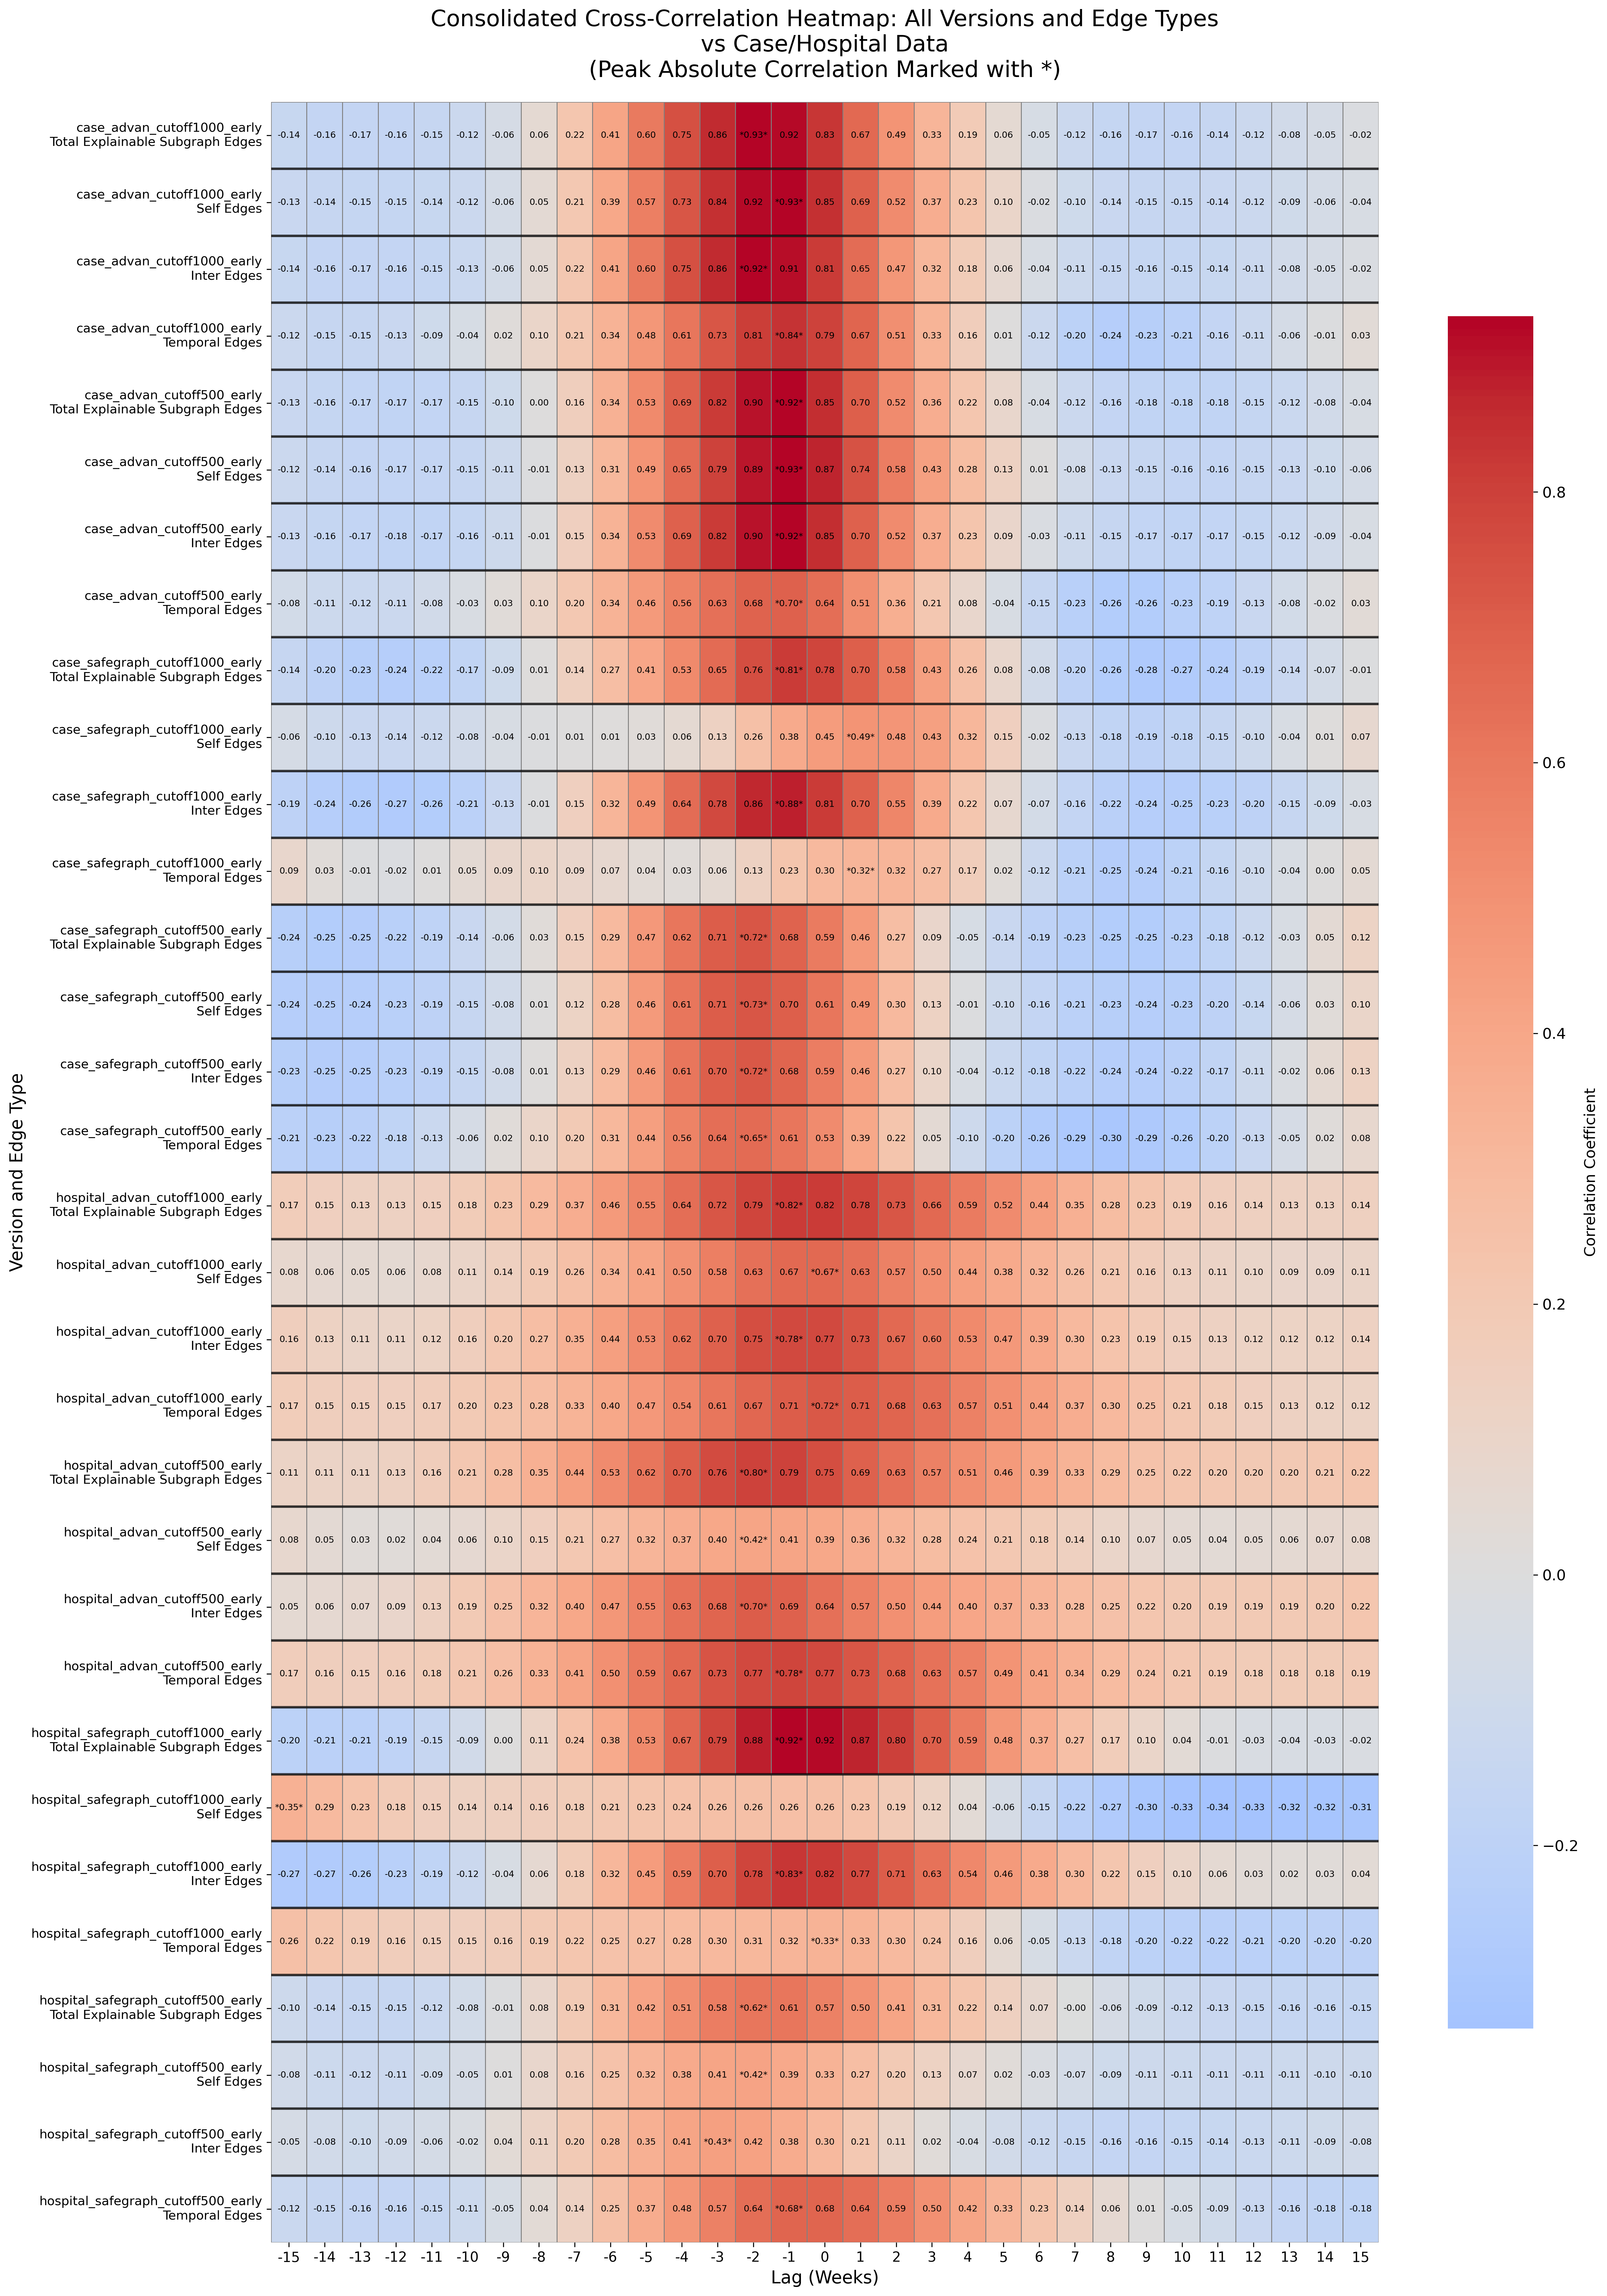

Saved consolidated correlation heatmap as PNG: consolidated_correlation_heatmap.png
\n================================================================================
CREATING SUMMARY CORRELATION HEATMAP (ORIGINAL FORMAT)


/local/ipykernel_2150296/1317589835.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.92
(lag: -2)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.iloc[i, j] = f"{corr_val:.2f}\n(lag: {int(lag_val)})"
/local/ipykernel_2150296/1317589835.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.92
(lag: -1)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.iloc[i, j] = f"{corr_val:.2f}\n(lag: {int(lag_val)})"
/local/ipykernel_2150296/1317589835.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.88
(lag: -1)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.iloc[i, j] = f"{corr_val:.2f

Saved summary correlation heatmap to: correlation_summary_heatmap.pdf


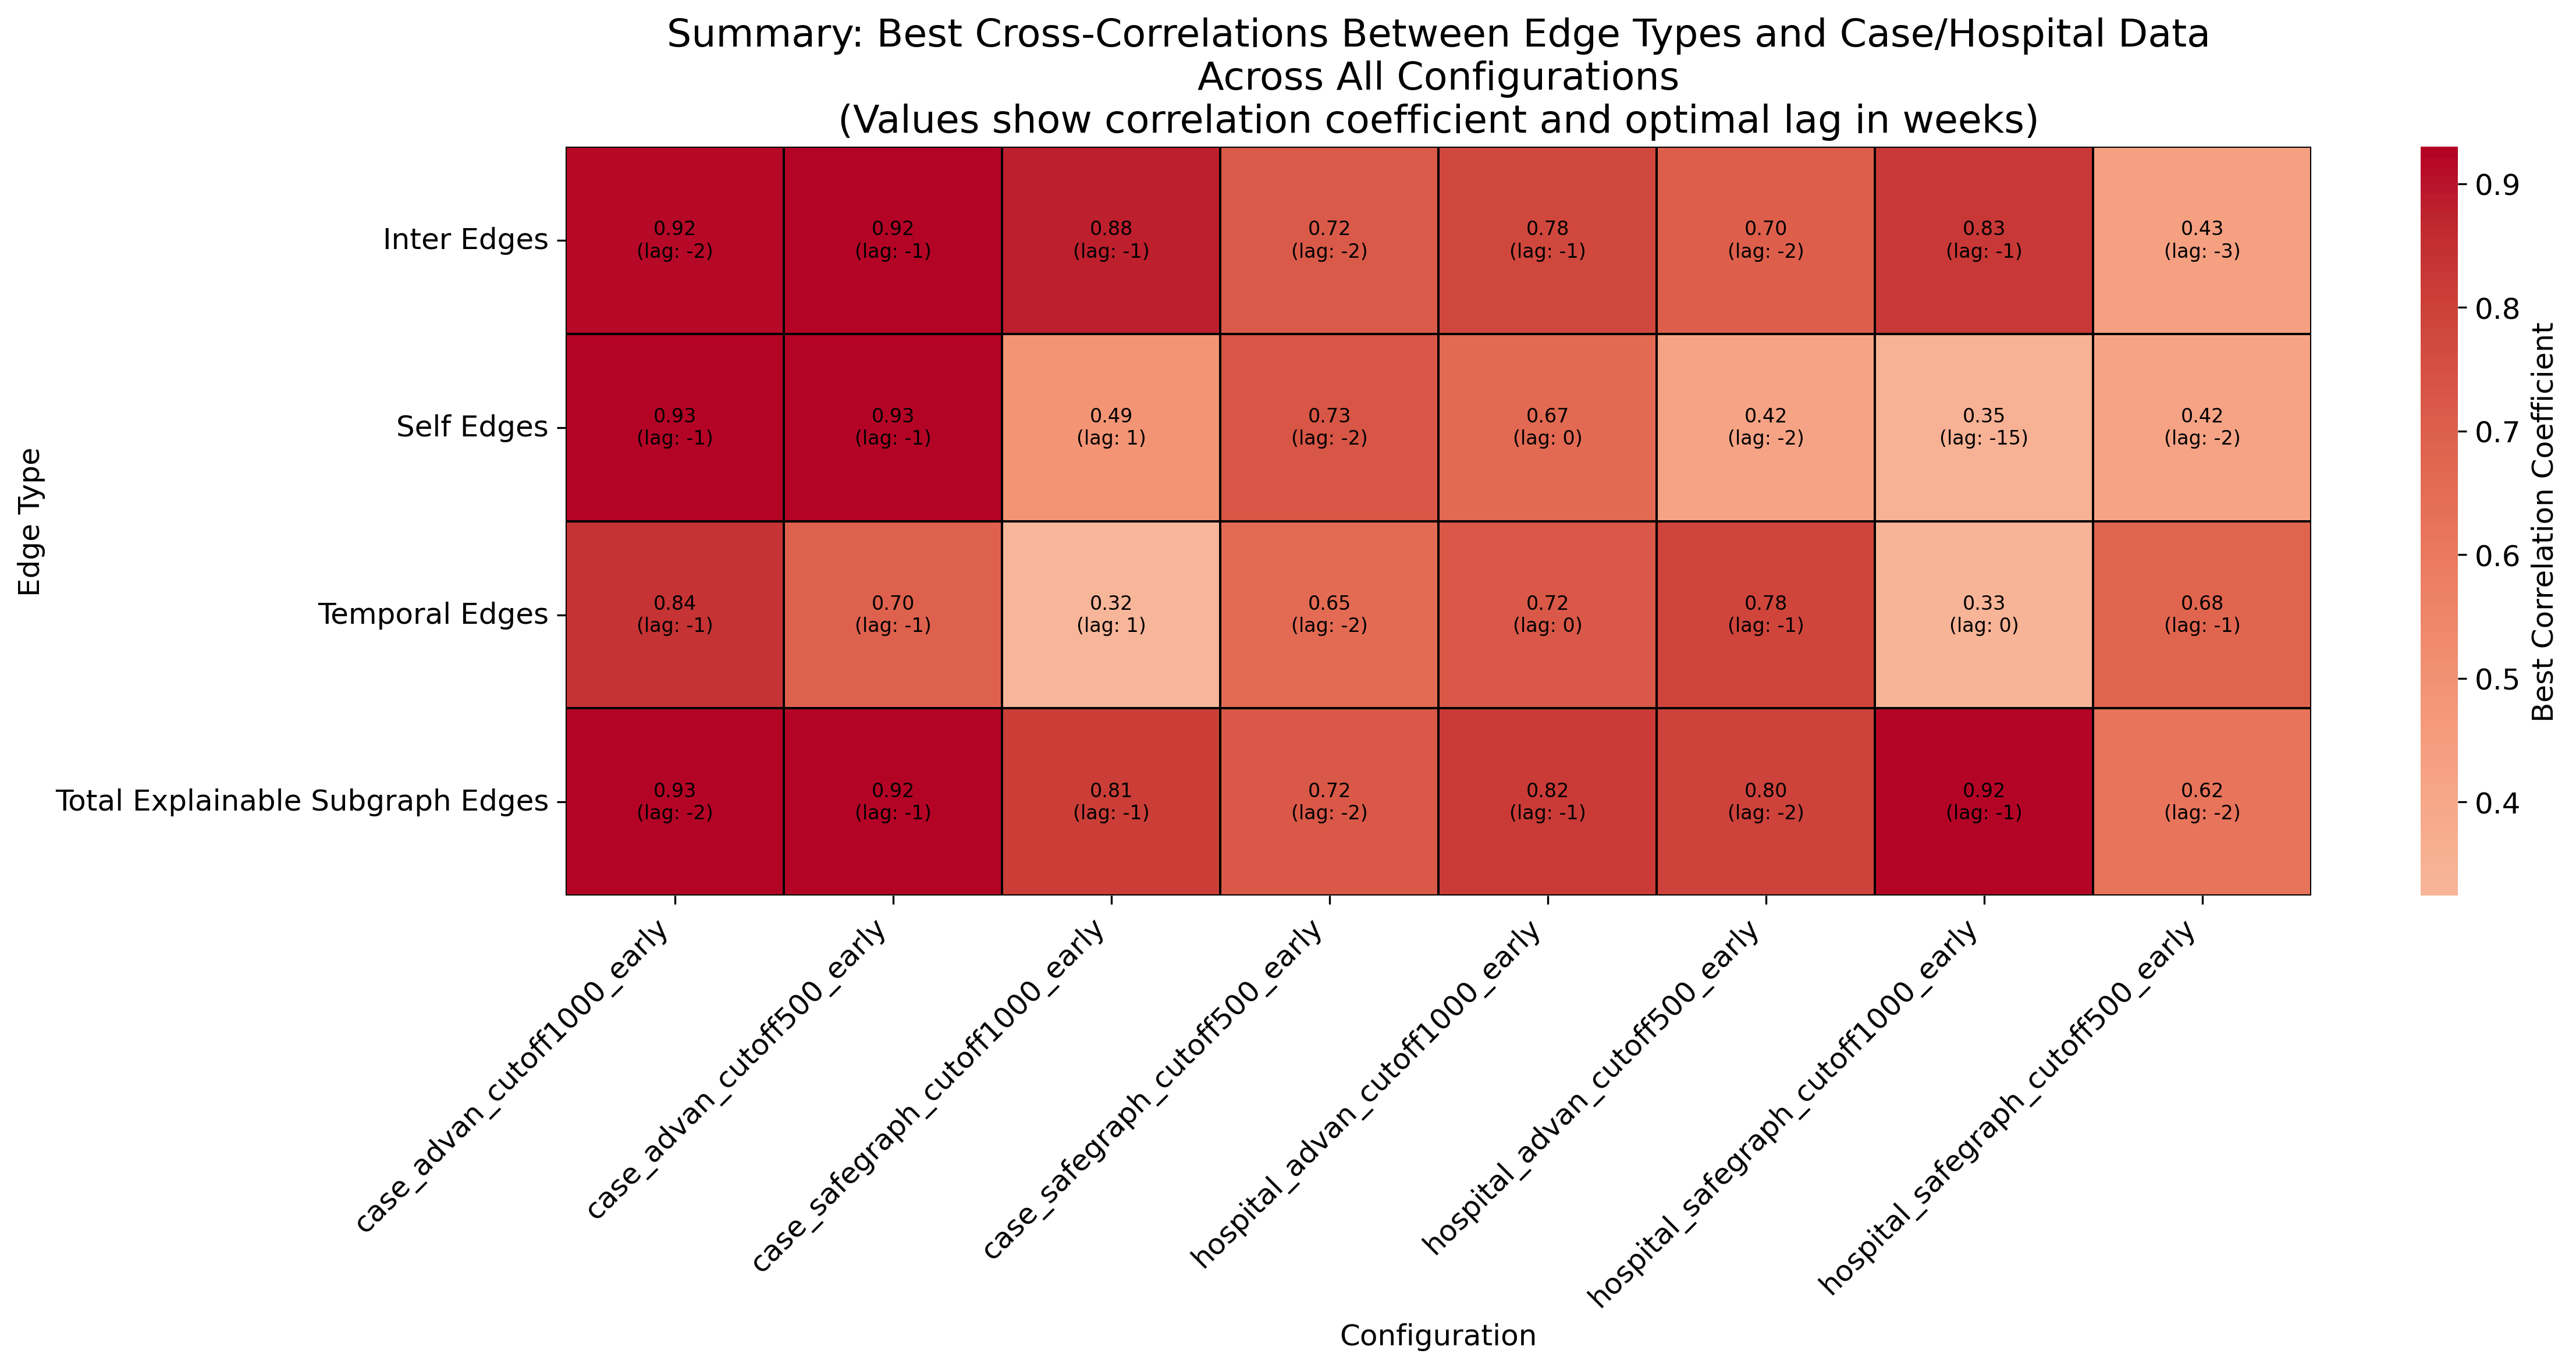

Saved summary correlation heatmap as PNG: correlation_summary_heatmap.png


In [15]:
def create_summary_correlation_heatmap(correlation_results, save_path=None):
    """
    Create a summary heatmap showing best lag correlations for all configurations and edge types
    """
    if not correlation_results:
        print("No correlation results to summarize")
        return None, None
    
    # Build summary data
    summary_data = []
    
    for config_name, correlations in correlation_results.items():
        for edge_type, corr_data in correlations.items():
            best_lag = corr_data['best_lag']
            best_corr = corr_data['correlation'][corr_data['lag_range'].index(best_lag)]
            
            summary_data.append({
                'Configuration': config_name,
                'Edge Type': edge_type,
                'Best Lag': best_lag,
                'Best Correlation': best_corr
            })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Create pivot table for heatmap
    pivot_df = summary_df.pivot(index='Edge Type', columns='Configuration', values='Best Correlation')
    
    # Create annotation DataFrame with correlation values and lag information
    lag_pivot = summary_df.pivot(index='Edge Type', columns='Configuration', values='Best Lag')
    annot_df = pivot_df.copy()
    
    for i in range(len(annot_df.index)):
        for j in range(len(annot_df.columns)):
            edge_type = annot_df.index[i]
            config = annot_df.columns[j]
            corr_val = pivot_df.iloc[i, j]
            lag_val = lag_pivot.iloc[i, j]
            
            if pd.notna(corr_val) and pd.notna(lag_val):
                annot_df.iloc[i, j] = f"{corr_val:.2f}\n(lag: {int(lag_val)})"
            else:
                annot_df.iloc[i, j] = ""
    
    # Create the heatmap
    fig_width = max(12, len(pivot_df.columns) * 2)
    fig_height = max(8, len(pivot_df.index) * 1.5)
    
    plt.figure(figsize=(fig_width, fig_height))
    
    sns.heatmap(
        pivot_df,
        annot=annot_df,
        fmt="",
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        linecolor='black',
        cbar_kws={'label': 'Best Correlation Coefficient'},
        annot_kws={"size": 8, "color": "black", "fontweight": "normal", "va": "center", "ha": "center"}
    )
    
    plt.title('Summary: Best Cross-Correlations Between Edge Types and Case/Hospital Data\nAcross All Configurations\n(Values show correlation coefficient and optimal lag in weeks)', 
              fontsize=16)
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Edge Type', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved summary correlation heatmap to: {save_path}")
    
    return plt.gcf(), plt.gca()

def create_consolidated_correlation_heatmap(correlation_results, save_path=None):
    """
    Create one large heatmap with all versions and edge types
    Rows ordered first by version, then by edge type
    """
    if not correlation_results:
        print("No correlation results to create consolidated heatmap")
        return None, None
    
    # Get lag range from first configuration
    first_config = next(iter(correlation_results.values()))
    first_edge = next(iter(first_config.values()))
    lag_range = first_edge['lag_range']
    
    # Build consolidated data with proper ordering
    consolidated_data = []
    
    # Sort configurations (versions) alphabetically
    sorted_configs = sorted(correlation_results.keys())
    
    # Define edge type order
    edge_type_order = [
        'Total Explainable Subgraph Edges',
        'Self Edges', 
        'Inter Edges',
        'Temporal Edges'
    ]
    
    for config_name in sorted_configs:
        correlations = correlation_results[config_name]
        
        # Process edge types in specified order
        for edge_type in edge_type_order:
            if edge_type in correlations:
                corr_data = correlations[edge_type]
                correlation_array = corr_data['correlation']
                
                # Create row identifier
                row_label = f"{config_name}\n{edge_type}"
                row_data = {'Version_EdgeType': row_label}
                
                # Add correlation values for each lag
                for i, lag in enumerate(lag_range):
                    if i < len(correlation_array):
                        row_data[lag] = correlation_array[i]
                    else:
                        row_data[lag] = np.nan
                
                consolidated_data.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(consolidated_data)
    df = df.set_index('Version_EdgeType')
    
    # Create annotation DataFrame with formatted values and stars for max absolute correlation
    annot_df = df.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    
    # Mark maximum absolute correlation for each row with stars
    for index, row in df.iterrows():
        numeric_row = row.dropna()
        if not numeric_row.empty:
            max_abs_lag_col = numeric_row.abs().idxmax()
            current_value_str = annot_df.loc[index, max_abs_lag_col]
            annot_df.loc[index, max_abs_lag_col] = f"*{current_value_str}*"
    
    # Create the large heatmap
    fig_width = max(16, len(lag_range) * 0.6)
    fig_height = max(12, len(df) * 0.8)
    
    plt.figure(figsize=(fig_width, fig_height))
    
    sns.heatmap(
        df,
        annot=annot_df,
        fmt="",
        cmap='coolwarm',
        center=0,
        linewidths=0.3,
        linecolor='gray',
        cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
        annot_kws={"size": 7, "color": "black", "fontweight": "normal", "va": "center", "ha": "center"}
    )
    
    plt.title('Consolidated Cross-Correlation Heatmap: All Versions and Edge Types\nvs Case/Hospital Data\n(Peak Absolute Correlation Marked with *)', 
              fontsize=18, pad=20)
    plt.xlabel('Lag (Weeks)', fontsize=14)
    plt.ylabel('Version and Edge Type', fontsize=14)
    
    # Customize y-axis labels for better readability
    plt.yticks(rotation=0, fontsize=10)
    plt.xticks(fontsize=11)
    
    # Add subtle grid lines to separate versions
    ax = plt.gca()
    
    # Add horizontal lines to separate versions
    version_boundaries = []
    current_version = None
    for i, label in enumerate(df.index):
        version = label.split('\\n')[0]
        if current_version is not None and version != current_version:
            version_boundaries.append(i)
        current_version = version
    
    # Draw separator lines between versions
    for boundary in version_boundaries:
        ax.axhline(y=boundary, color='black', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved consolidated correlation heatmap to: {save_path}")
    
    return plt.gcf(), plt.gca()

# Create consolidated correlation heatmap
if correlation_results:
    print("\\n" + "=" * 80)
    print("CREATING CONSOLIDATED CORRELATION HEATMAP")
    print("=" * 80)
    
    consolidated_fig, consolidated_ax = create_consolidated_correlation_heatmap(
        correlation_results, 
        save_path='consolidated_correlation_heatmap.pdf'
    )
    plt.show()
    
    # Also save as PNG
    if consolidated_fig:
        consolidated_fig.savefig('consolidated_correlation_heatmap.png', bbox_inches='tight', dpi=300)
        print("Saved consolidated correlation heatmap as PNG: consolidated_correlation_heatmap.png")
        plt.close(consolidated_fig)

# Create original summary correlation heatmap (for comparison)
if correlation_results:
    print("\\n" + "=" * 80)
    print("CREATING SUMMARY CORRELATION HEATMAP (ORIGINAL FORMAT)")
    print("=" * 80)
    
    summary_fig, summary_ax = create_summary_correlation_heatmap(
        correlation_results, 
        save_path='correlation_summary_heatmap.pdf'
    )
    plt.show()
    
    # Also save as PNG
    if summary_fig:
        summary_fig.savefig('correlation_summary_heatmap.png', bbox_inches='tight', dpi=300)
        print("Saved summary correlation heatmap as PNG: correlation_summary_heatmap.png")
        plt.close(summary_fig)
